In [1]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
uploaded = files.upload()

for fn in uploaded.keys():
  print('"{name}" carregado com sucesso'.format(name=fn))

csv_filename = list(uploaded.keys())[0]
print(f"Arquivo '{csv_filename}' carregado")

df = pd.read_csv(csv_filename)
display(df.head())

Saving navegacao_analysis_results.csv to navegacao_analysis_results (1).csv
"navegacao_analysis_results (1).csv" carregado com sucesso
Arquivo 'navegacao_analysis_results (1).csv' carregado


,test_type,agent_count,grid_rows,grid_cols,mean_time_s,grid_cells,distribution_type,mean_path_length,run_id,time_s,path_length
0,agent_count,1.0,30,30,0.000418,NaN,NaN,NaN,NaN,NaN,NaN
1,agent_count,10.0,30,30,0.006994,NaN,NaN,NaN,NaN,NaN,NaN
2,agent_count,25.0,30,30,0.013427,NaN,NaN,NaN,NaN,NaN,NaN
3,agent_count,50.0,30,30,0.025968,NaN,NaN,NaN,NaN,NaN,NaN
4,agent_count,100.0,30,30,0.061933,NaN,NaN,NaN,NaN,NaN,NaN


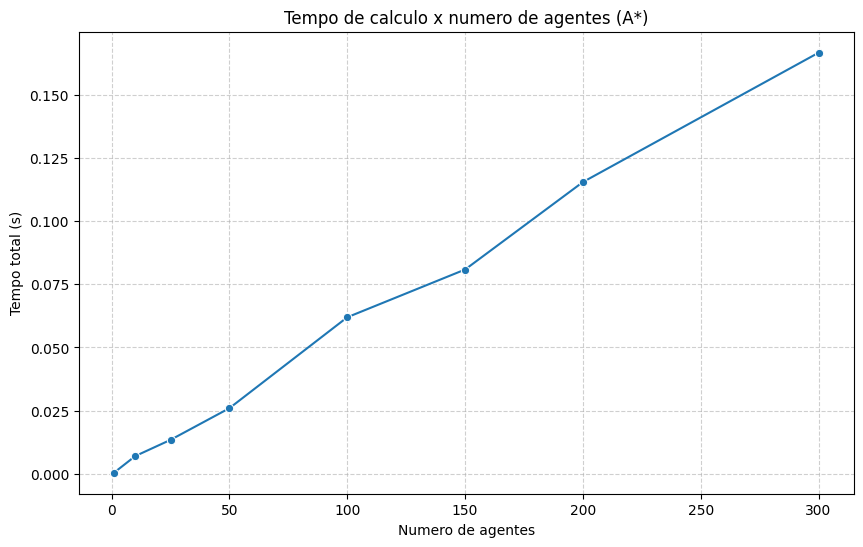

In [5]:
data = df[df['test_type'] == 'agent_count'].copy()

plt.figure(figsize=(10, 6))
sns.lineplot(data=data, x='agent_count', y='mean_time_s', marker='o')

plt.title('Tempo de calculo x numero de agentes (A*)')
plt.xlabel('Numero de agentes')
plt.ylabel('Tempo total (s)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('grafico_1_agentes.png')
plt.show()

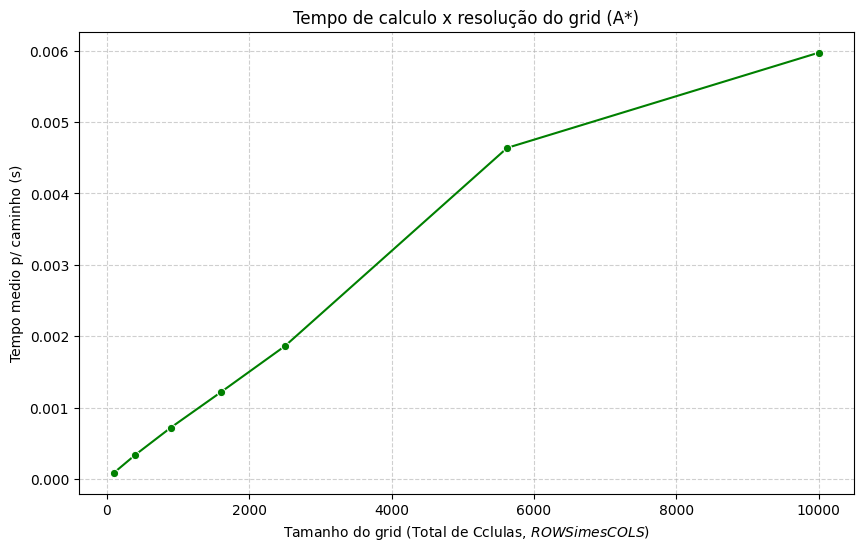

In [6]:
data = df[df['test_type'] == 'resolution'].copy()

plt.figure(figsize=(10, 6))
sns.lineplot(data=data, x='grid_cells', y='mean_time_s', marker='o', color='green')

plt.title('Tempo de calculo x resolução do grid (A*)')
plt.xlabel('Tamanho do grid (Total de Cclulas, $ROWS \times COLS$)')
plt.ylabel('Tempo medio p/ caminho (s)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('grafico_2_resolucao.png')
plt.show()

/tmp/ipython-input-217704025.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='distribution_type', y='mean_time_s', ax=ax1, palette='muted', alpha=0.8)


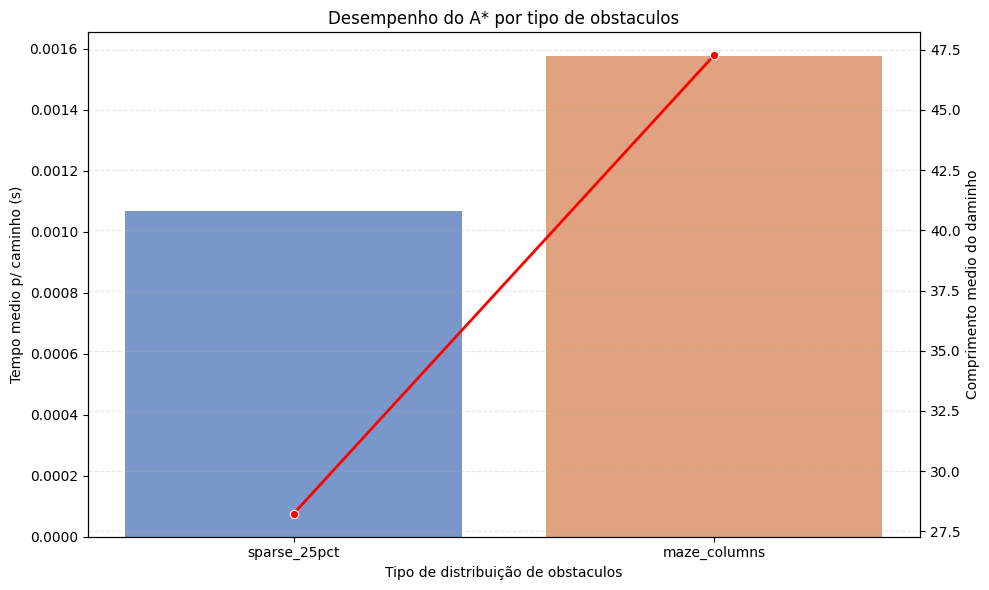

In [7]:
data = df[df['test_type'] == 'distribution'].copy()

fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(data=data, x='distribution_type', y='mean_time_s', ax=ax1, palette='muted', alpha=0.8)
ax1.set_ylabel('Tempo medio p/ caminho (s)')
ax1.set_xlabel('Tipo de distribuição de obstaculos')

ax2 = ax1.twinx()
sns.lineplot(data=data, x='distribution_type', y='mean_path_length', ax=ax2, marker='o', color='red', lw=2)
ax2.set_ylabel('Comprimento medio do daminho')

plt.title('Desempenho do A* por tipo de obstaculos')
plt.grid(True, linestyle='--', alpha=0.3)
fig.tight_layout()
plt.savefig('grafico_3_distribuicao.png')
plt.show()

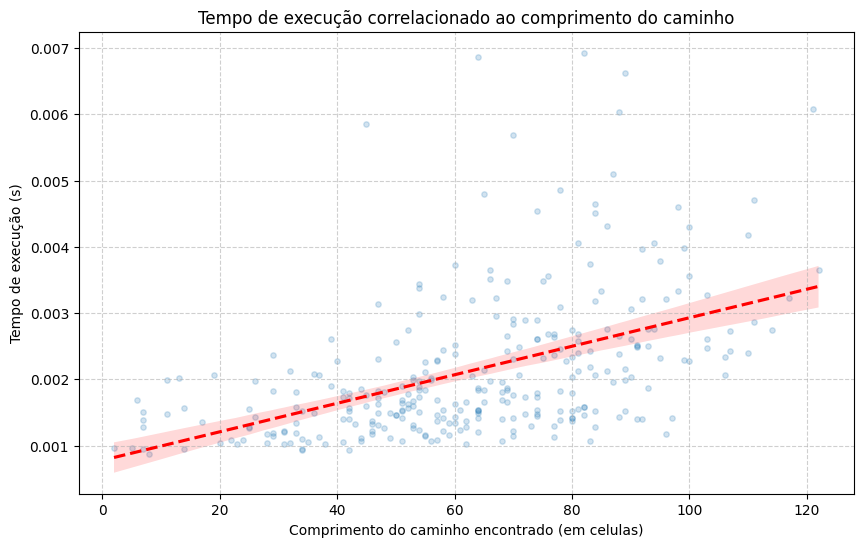

In [8]:
data = df[df['test_type'] == 'path_length'].copy()

plt.figure(figsize=(10, 6))
sns.regplot(
    data=data,
    x='path_length',
    y='time_s',
    scatter_kws={'alpha':0.2, 's':15},
    line_kws={'color':'red', 'linestyle':'--'}
)
plt.title('Tempo de execução correlacionado ao comprimento do caminho')
plt.xlabel('Comprimento do caminho encontrado (em celulas)')
plt.ylabel('Tempo de execução (s)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('grafico_4_comprimento.png')
plt.show()